# Avaliação — DCA1

Notebook fino reusando `utils_eval.py` (loader unificado) e `utils.py` (plot/aggregação legado).

**Observação:** Zero-shot **MOCKADO** (NaN placeholders) até a inferência real ser produzida.

## Legenda das nomenclaturas de modelos

Cada `model_type` codifica três informações: **arquitetura**, **origem dos pesos iniciais** e **regime de treino**.

| Label                     | Arquitetura                                     | Pesos iniciais                                       | Regime                                  | Stage       |
|---------------------------|-------------------------------------------------|------------------------------------------------------|-----------------------------------------|-------------|
| `UNet18`                  | U-Net (encoder ResNet-18)                       | Aleatórios (Kaiming)                                 | Treino do zero                          | `scratch`   |
| `UNet50`                  | U-Net (encoder ResNet-50)                       | Aleatórios (Kaiming)                                 | Treino do zero                          | `scratch`   |
| `VSUNet18`                | U-Net (encoder ResNet-18)                       | Pré-treinados em **VessShape**                       | Fine-tuning no dataset alvo             | `finetune`  |
| `VSUNet50`                | U-Net (encoder ResNet-50)                       | Pré-treinados em **VessShape**                       | Fine-tuning no dataset alvo             | `finetune`  |
| `IN-UNet18`               | U-Net (encoder ResNet-18)                       | Pré-treinados em **ImageNet**                        | Fine-tuning no dataset alvo             | `finetune`  |
| `IN-UNet50`               | U-Net (encoder ResNet-50)                       | Pré-treinados em **ImageNet**                        | Fine-tuning no dataset alvo             | `finetune`  |
| `LiteMedSAM-FT`           | LiteMedSAM (encoder ViT leve do MedSAM)         | Pré-treinados em **MedSAM** (LiteMedSAM checkpoint) | Fine-tuning no dataset alvo             | `finetune`  |
| `Zero-Shot VSUNet18`      | U-Net (encoder ResNet-18)                       | Pré-treinados em **VessShape**                       | **Sem** fine-tuning — inferência direta | `zero_shot` |
| `Zero-Shot VSUNet50`      | U-Net (encoder ResNet-50)                       | Pré-treinados em **VessShape**                       | **Sem** fine-tuning — inferência direta | `zero_shot` |
| `Zero-Shot IN-UNet18`     | U-Net (encoder ResNet-18)                       | Pré-treinados em **ImageNet**                        | **Sem** fine-tuning — inferência direta | `zero_shot` |
| `Zero-Shot IN-UNet50`     | U-Net (encoder ResNet-50)                       | Pré-treinados em **ImageNet**                        | **Sem** fine-tuning — inferência direta | `zero_shot` |
| `Zero-Shot LiteMedSAM`    | LiteMedSAM (encoder ViT leve do MedSAM)         | Pré-treinados em **MedSAM**                          | **Sem** fine-tuning — inferência direta | `zero_shot` |
| `Zero-Shot LiteMedSAM+IN` | LiteMedSAM (encoder ViT leve do MedSAM)         | Pré-treinados em **MedSAM** + norm. ImageNet entrada | **Sem** fine-tuning — inferência direta | `zero_shot` |
| `... (mock)`              | —                                               | —                                                    | Placeholder com `NaN`                   | `zero_shot` |

**Convenções:**
- `VS` = pré-treino em **VessShape** (dataset sintético próprio do projeto).
- `IN-` = pré-treino em **ImageNet**.
- `-FT` = fine-tuning a partir de checkpoint pré-treinado.
- `+IN` = normalização ImageNet aplicada na **entrada** do modelo (`_PreprocessModel` wrapper) — não altera os pesos, só pré-processa o input.
- `Zero-Shot` = nenhum fine-tuning no dataset alvo (`num_samples = 0`); gerado por `run_zero_shot_inference.ipynb`.
- Sufixo ` (mock)` = placeholder (`utils_eval.generate_mock_zero_shot`, `is_mock=True`, `NaN`) usado **apenas** como fallback enquanto o CSV de zero-shot real não existir.

**Eixo de comparação do paper:**
- `UNet*` (scratch) vs `IN-UNet*` (ImageNet) vs `VSUNet*` (VessShape) → mede o ganho do pré-treino em VessShape sobre as alternativas.
- `Zero-Shot *` em `num_samples = 0` (VSUNet / IN-UNet / LiteMedSAM) → mede a transferência sem fine-tuning de cada origem de pesos.
- `LiteMedSAM-FT` → baseline de modelo de segmentação médica de larga escala (com fine-tuning).
- `Zero-Shot LiteMedSAM` vs `Zero-Shot LiteMedSAM+IN` → valida H1 (normalização de entrada): se `+IN` tiver Dice > 0, a normalização ImageNet era necessária para os pesos originais do LiteMedSAM.

In [4]:
%load_ext autoreload
%autoreload 2

import os
import pandas as pd
from utils_eval import (
    load_dataset_results,
    load_dataset_per_image,
    save_result_matrices,
    build_summary_table,
    default_line_styles_7way,
    load_model_palette,
    report_coverage,
    METRICS,
    RESULTS_DIR,
    FIGURES_DIR,
    ensure_output_dirs,
)

ensure_output_dirs()  # cria results/ e figures/ se necessário
from utils import plot_mean_dice_score

# Paleta padronizada model_type -> cor (model_colors.yaml).
# Passada como color_map_override em todos os plots para cores consistentes cross-figure.
PALETTE = load_model_palette()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Carregar dados

In [5]:
DATASET = 'dca1'
MOCK_ZS = False  # zero-shot real disponível (run_zero_shot_inference.ipynb); mock só como fallback

df = load_dataset_results(DATASET, root='..', mock_zero_shot=MOCK_ZS)
print('shape =', df.shape)
df['model_type'].value_counts()

shape = (1002, 17)


model_type
IN-UNet18               165
LiteMedSAM-FT           165
IN-UNet50               165
VSUNet18                165
VSUNet50                165
UNet50                   90
UNet18                   82
Zero-Shot VSUNet18        1
Zero-Shot VSUNet50        1
Zero-Shot IN-UNet18       1
Zero-Shot IN-UNet50       1
Zero-Shot LiteMedSAM      1
Name: count, dtype: int64

## Matrizes de resultados (intermediárias)

Salvas em `results/` via `save_result_matrices`. Três regimes × duas granularidades:
- `<ds>_few_shot_results[_per_image].csv` — só few-shot (scratch + finetune).
- `<ds>_zero_shot_results[_per_image].csv` — só zero-shot.
- `<ds>_all_results[_per_image].csv` — few + zero-shot (matriz-base).

Granularidade média-por-run (sufixo vazio) e por-imagem (`_per_image`). Zero-shot mock não tem per-image.

In [6]:
# Matriz média-por-run (df já carregado) — few-shot / zero-shot / all
paths_run = save_result_matrices(df, DATASET)

# Matriz por imagem — few-shot / zero-shot / all
df_per_image = load_dataset_per_image(DATASET, root='..')
paths_img = save_result_matrices(df_per_image, DATASET, suffix='_per_image')

print('run-mean :', df.shape, '->', {k: __import__('os').path.basename(v) for k, v in paths_run.items()})
print('per-image:', df_per_image.shape, '->', {k: __import__('os').path.basename(v) for k, v in paths_img.items()})

run-mean : (1002, 17) -> {'few_shot': 'dca1_few_shot_results.csv', 'zero_shot': 'dca1_zero_shot_results.csv', 'all': 'dca1_all_results.csv'}
per-image: (21042, 18) -> {'few_shot': 'dca1_few_shot_results_per_image.csv', 'zero_shot': 'dca1_zero_shot_results_per_image.csv', 'all': 'dca1_all_results_per_image.csv'}


## 2. Sanidade — cobertura por modelo / stage

In [7]:
coverage = report_coverage(df)
print('Stages presentes:', sorted(df['stage'].unique()))
if df['is_mock'].any():
    n_mock = int(df['is_mock'].sum())
    print(f'[INFO] {n_mock} linha(s) zero-shot MOCK (NaN). Substituir quando inferência real estiver pronta.')

expected = {'UNet18','UNet50','VSUNet18','VSUNet50','IN-UNet18','IN-UNet50','LiteMedSAM-FT'}
missing = expected - set(df['model_type'].unique())
if missing:
    print(f'[INFO] model_types ausentes (esperado em datasets completos): {sorted(missing)}')
coverage

Stages presentes: ['finetune', 'scratch', 'zero_shot']


,,count,min,max
model_type,stage,,,
IN-UNet18,finetune,165,1,20
IN-UNet50,finetune,165,1,20
LiteMedSAM-FT,finetune,165,1,20
UNet18,scratch,82,10,20
UNet50,scratch,90,10,20
VSUNet18,finetune,165,1,20
VSUNet50,finetune,165,1,20
Zero-Shot IN-UNet18,zero_shot,1,0,0
Zero-Shot IN-UNet50,zero_shot,1,0,0


## 3. Resumo (mean ± std) em num_samples ∈ [0, 1, 20]

In [8]:
SAMPLE_FILTER = [0, 1, 20]
summary = build_summary_table(df, sample_filter=SAMPLE_FILTER)
summary.to_csv(os.path.join(RESULTS_DIR, 'dca1_results_summary.csv'), index=False)
summary

,model_type,num_samples,mean_Accuracy,std_Accuracy,mean_IoU,std_IoU,mean_Precision,std_Precision,mean_Recall,std_Recall,mean_Dice,std_Dice,mean_AUC,std_AUC
0,IN-UNet18,1,0.951379,0.022732,0.202605,0.124741,0.641182,0.201827,0.271749,0.173287,0.304773,0.160586,0.780867,0.129923
1,IN-UNet18,20,0.975433,0.001356,0.578692,0.028335,0.772176,0.024133,0.717151,0.047542,0.726075,0.028183,0.984082,0.002747
2,IN-UNet50,1,0.963344,0.004451,0.318879,0.104547,0.754566,0.104017,0.389507,0.166071,0.456332,0.123345,0.853972,0.060048
3,IN-UNet50,20,0.977722,0.000735,0.612666,0.016717,0.784648,0.012450,0.745706,0.029886,0.756660,0.014074,0.978719,0.003952
4,LiteMedSAM-FT,1,0.950951,0.040312,0.365414,0.107687,0.694438,0.210899,0.488086,0.126675,0.508864,0.121400,0.918652,0.051005
5,LiteMedSAM-FT,20,0.977944,0.000466,0.627984,0.008627,0.772987,0.010808,0.781462,0.017205,0.769361,0.006627,0.987033,0.002060
6,UNet18,20,0.974072,0.001561,0.561989,0.021024,0.757290,0.037350,0.708192,0.051512,0.712120,0.022858,0.982335,0.003088
7,UNet50,20,0.975220,0.001063,0.571776,0.027307,0.768168,0.022597,0.709978,0.049656,0.718930,0.028179,0.979262,0.005889
8,VSUNet18,1,0.967459,0.005086,0.404343,0.072579,0.752095,0.077325,0.490337,0.126930,0.547335,0.079107,0.925165,0.042613
9,VSUNet18,20,0.978374,0.000783,0.625882,0.015512,0.790022,0.013737,0.759910,0.028908,0.767372,0.012521,0.989553,0.001098


## 3a. Resumo few-shot (scratch + finetune)

In [9]:
df_fs = df[df['stage'] != 'zero_shot']
summary_fs = build_summary_table(df_fs, sample_filter=[s for s in SAMPLE_FILTER if s > 0])
summary_fs

,model_type,num_samples,mean_Accuracy,std_Accuracy,mean_IoU,std_IoU,mean_Precision,std_Precision,mean_Recall,std_Recall,mean_Dice,std_Dice,mean_AUC,std_AUC
0,IN-UNet18,1,0.951379,0.022732,0.202605,0.124741,0.641182,0.201827,0.271749,0.173287,0.304773,0.160586,0.780867,0.129923
1,IN-UNet18,20,0.975433,0.001356,0.578692,0.028335,0.772176,0.024133,0.717151,0.047542,0.726075,0.028183,0.984082,0.002747
2,IN-UNet50,1,0.963344,0.004451,0.318879,0.104547,0.754566,0.104017,0.389507,0.166071,0.456332,0.123345,0.853972,0.060048
3,IN-UNet50,20,0.977722,0.000735,0.612666,0.016717,0.784648,0.012450,0.745706,0.029886,0.756660,0.014074,0.978719,0.003952
4,LiteMedSAM-FT,1,0.950951,0.040312,0.365414,0.107687,0.694438,0.210899,0.488086,0.126675,0.508864,0.121400,0.918652,0.051005
5,LiteMedSAM-FT,20,0.977944,0.000466,0.627984,0.008627,0.772987,0.010808,0.781462,0.017205,0.769361,0.006627,0.987033,0.002060
6,UNet18,20,0.974072,0.001561,0.561989,0.021024,0.757290,0.037350,0.708192,0.051512,0.712120,0.022858,0.982335,0.003088
7,UNet50,20,0.975220,0.001063,0.571776,0.027307,0.768168,0.022597,0.709978,0.049656,0.718930,0.028179,0.979262,0.005889
8,VSUNet18,1,0.967459,0.005086,0.404343,0.072579,0.752095,0.077325,0.490337,0.126930,0.547335,0.079107,0.925165,0.042613
9,VSUNet18,20,0.978374,0.000783,0.625882,0.015512,0.790022,0.013737,0.759910,0.028908,0.767372,0.012521,0.989553,0.001098


## 3b. Resumo zero-shot (N=0)

In [10]:
df_zs = df[(df['stage'] == 'zero_shot') & (~df['is_mock'])]
if df_zs.empty:
    print('[INFO] Sem dados zero-shot reais.')
else:
    summary_zs = (df_zs
                  .groupby('model_type')[['Dice', 'IoU', 'Precision', 'Recall', 'AUC']]
                  .mean()
                  .sort_values('Dice', ascending=False))
    summary_zs

## 4. Plots principais — todas as métricas (Accuracy, IoU, Precision, Recall, Dice, AUC)

Loop sobre as 6 métricas. Cada métrica produz 1 SVG (`dca1_<metric>.svg`). As cores
dos modelos vêm do `model_colors.yaml` (`PALETTE`) para consistência cross-figure.
`Y_LIMITS_BY_METRIC` permite zoom-in por métrica (None = autoscale).

── Métrica: Accuracy ──


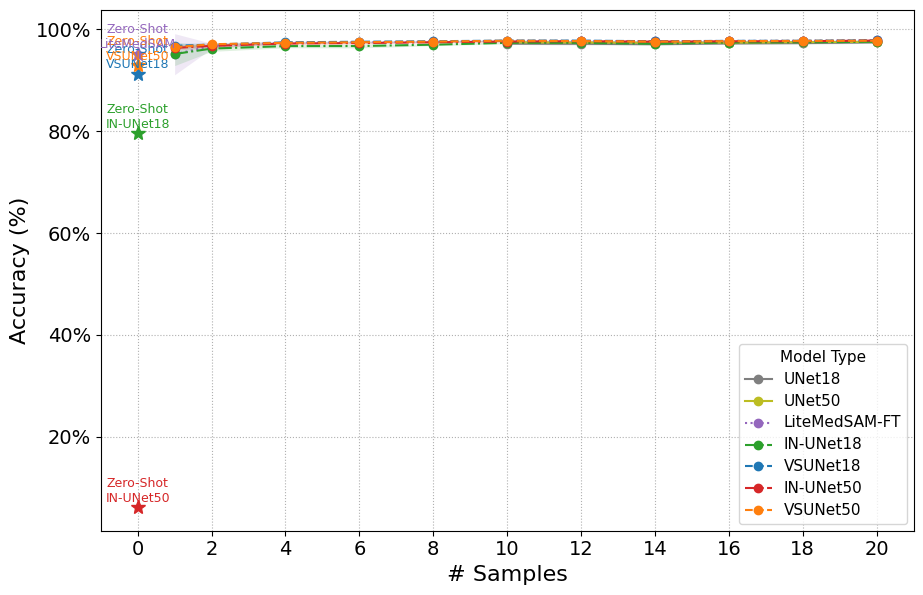

── Métrica: IoU ──


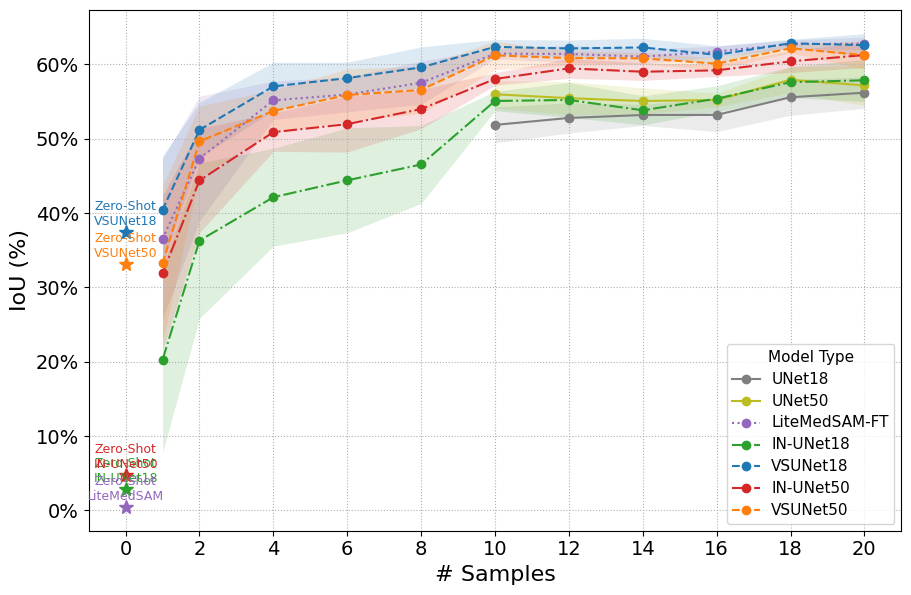

── Métrica: Precision ──


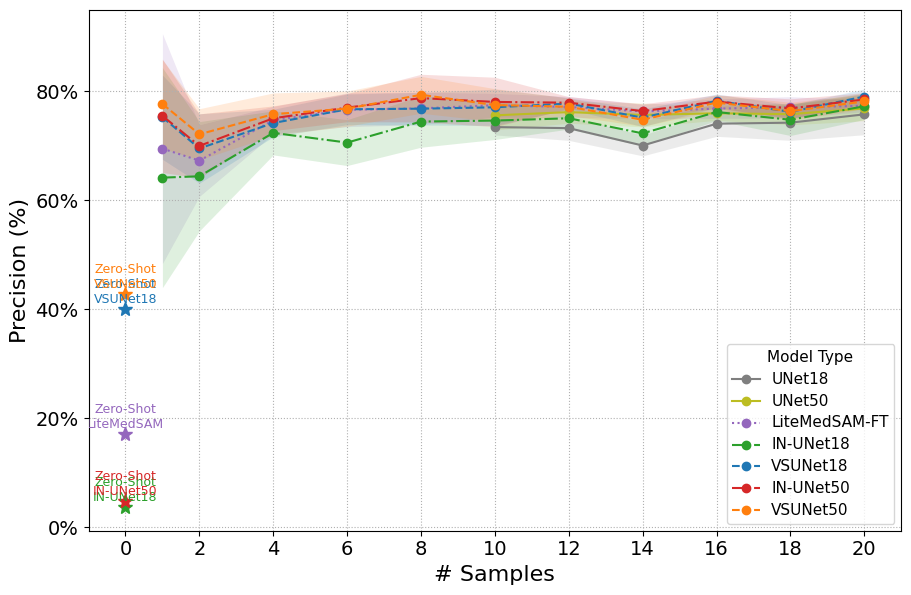

── Métrica: Recall ──


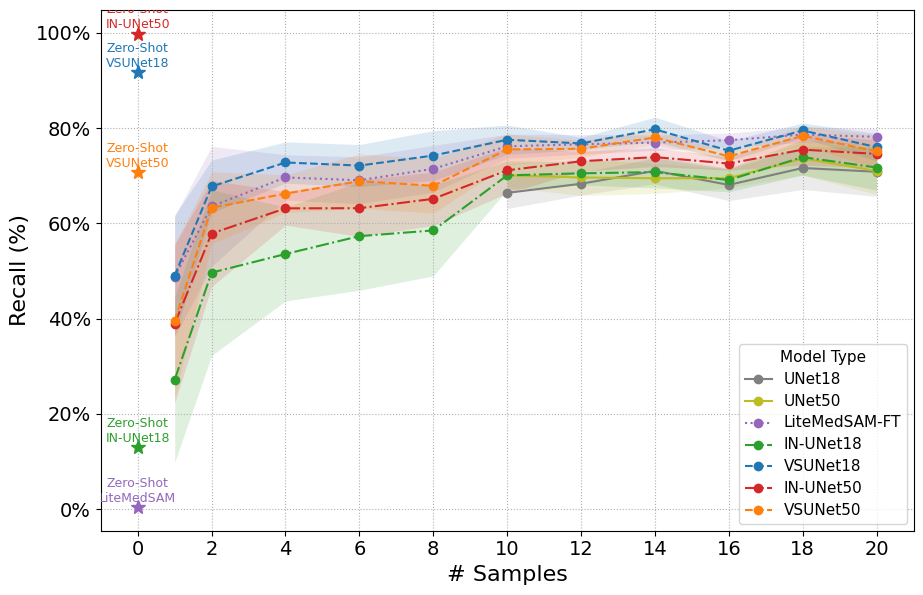

── Métrica: Dice ──


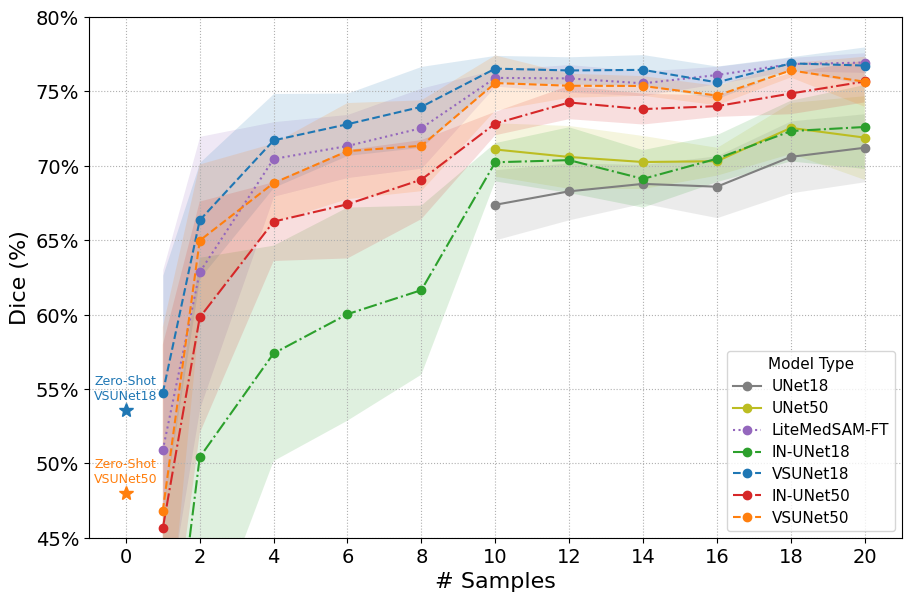

── Métrica: AUC ──


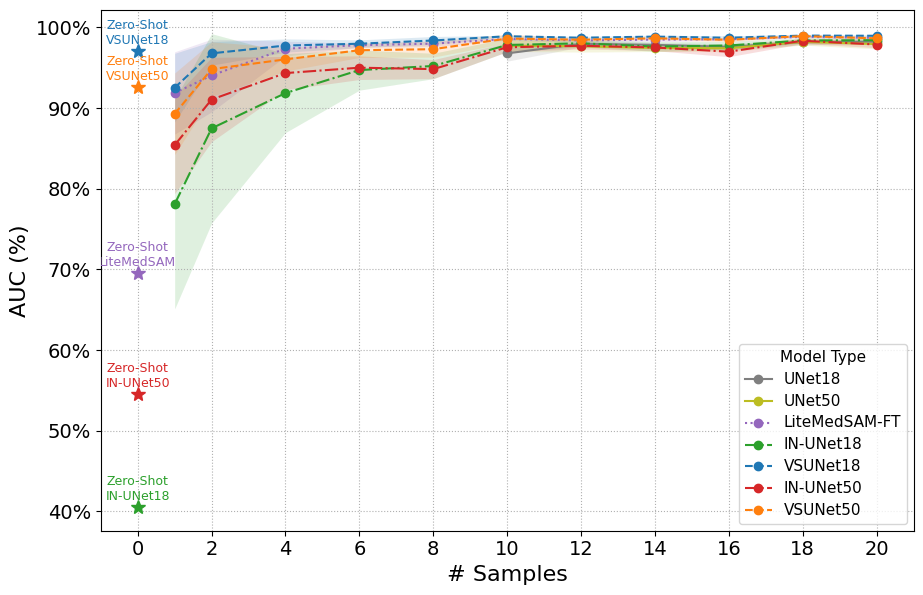

In [11]:
line_styles = default_line_styles_7way()

# Per-metric y_limits. None -> autoscale. Ajuste por métrica conforme conveniente para o paper.
Y_LIMITS_BY_METRIC = {
    'Dice':      (0.45, 0.80),
    'IoU':       None,
    'Accuracy':  None,
    'Precision': None,
    'Recall':    None,
    'AUC':       None,
}

FONT_SIZES = {
    'title': 16, 'xlabel': 16, 'ylabel': 16,
    'xaxis': 14, 'yaxis': 14,
    'legend': 11, 'zero_shot_annotation': 9, 'zero_shot_marker': 10,
}

for metric in METRICS:
    print(f'── Métrica: {metric} ──')
    plot_mean_dice_score(
        df,
        dataset_name='DCA1',
        hue='model_type',
        x_data='num_samples',
        y_data=metric,
        y_limits=Y_LIMITS_BY_METRIC.get(metric),
        line_styles=line_styles,
        color_map_override=PALETTE,
        annotate_zero_shot=True,
        title='',
        legend_title='Model Type',
        xlabel='# Samples',
        percentage=True,
        save_path=os.path.join(FIGURES_DIR, f'dca1_{metric.lower()}.svg'),
        font_sizes=FONT_SIZES,
        figsize=(9, 6),
        legend_loc='lower right',
        share_zero_shot_color_with='finetuned',
    )

## 5. Subplots focados — família ResNet18, ResNet50, LiteMedSAM (todas as métricas)

Loop externo sobre métricas, loop interno sobre as 3 famílias. Cada combinação produz
1 SVG (`dca1_<family>_<metric>.svg`).

── Métrica: Accuracy ──


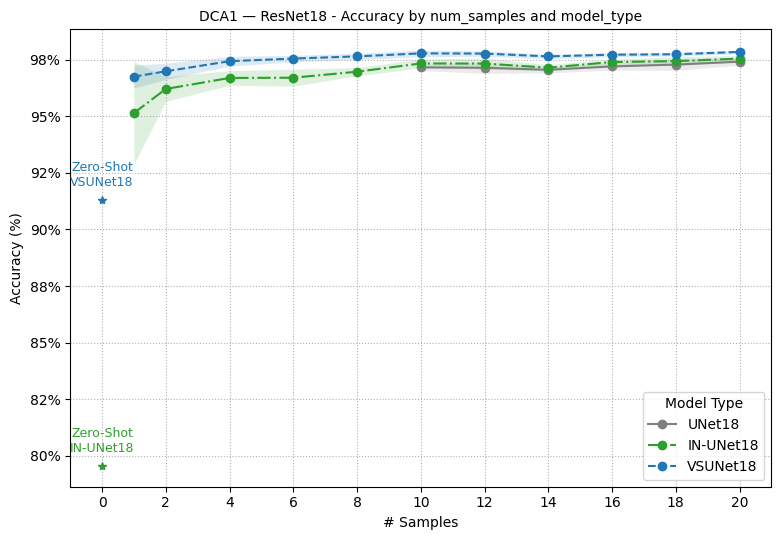

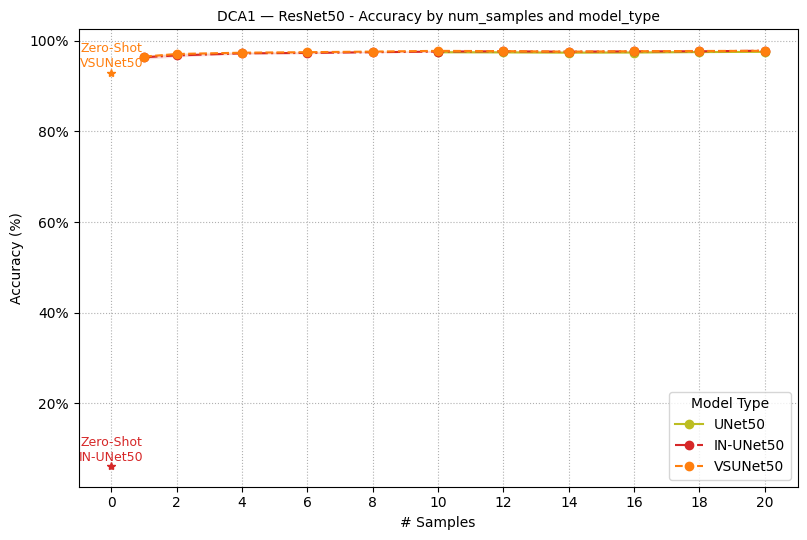

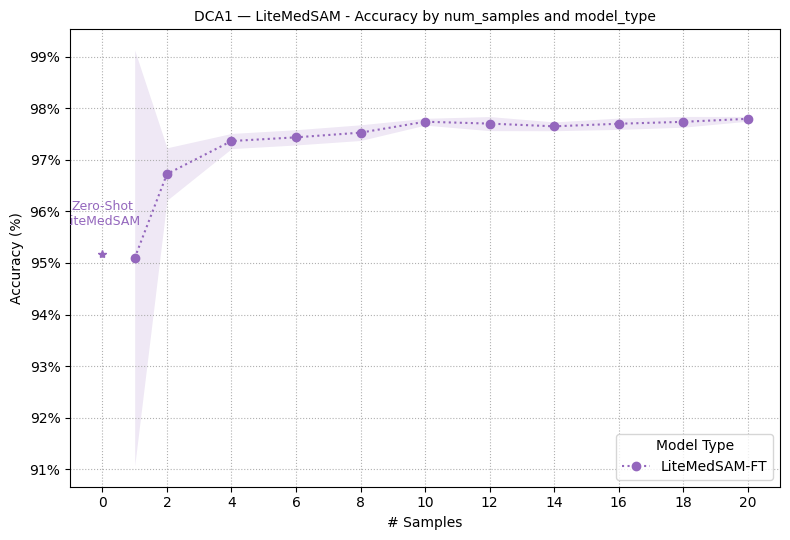

── Métrica: IoU ──


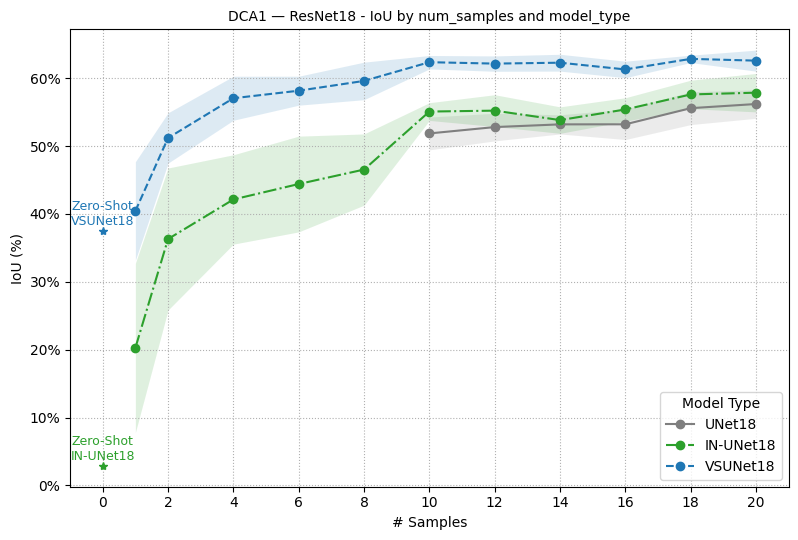

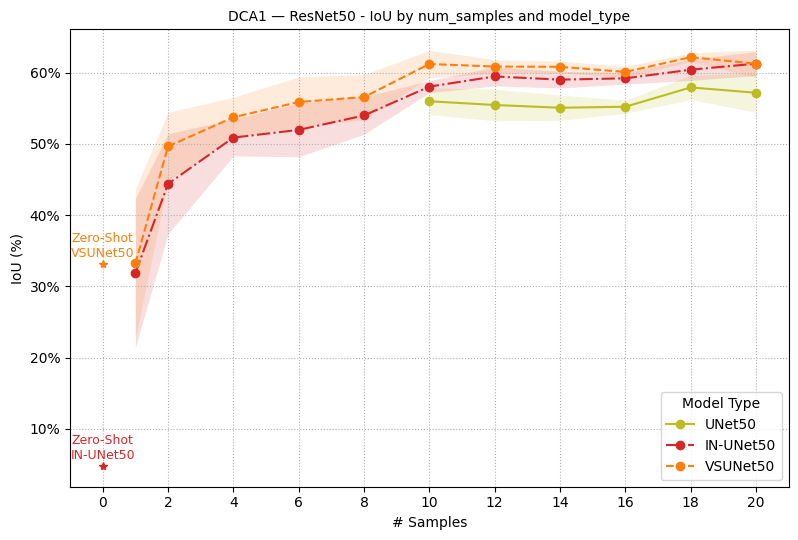

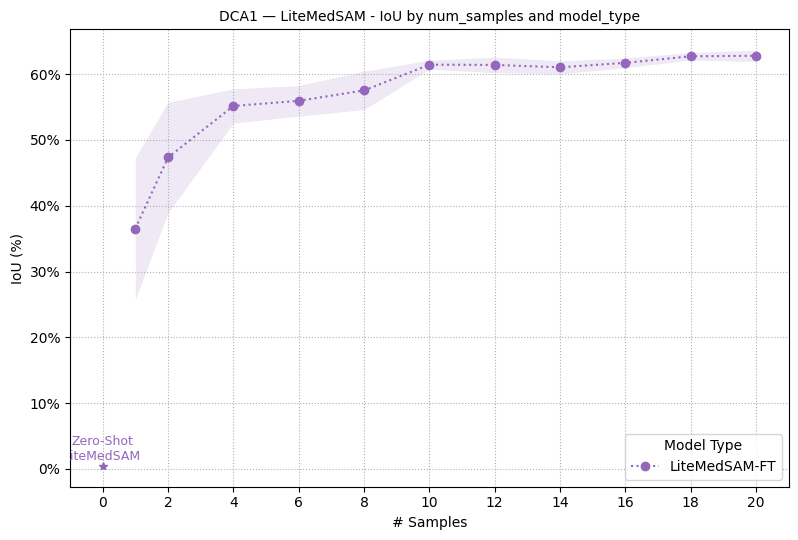

── Métrica: Precision ──


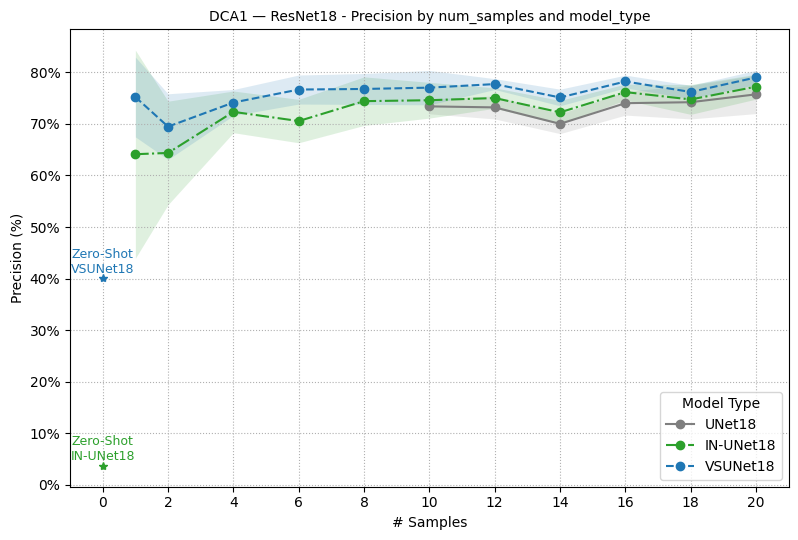

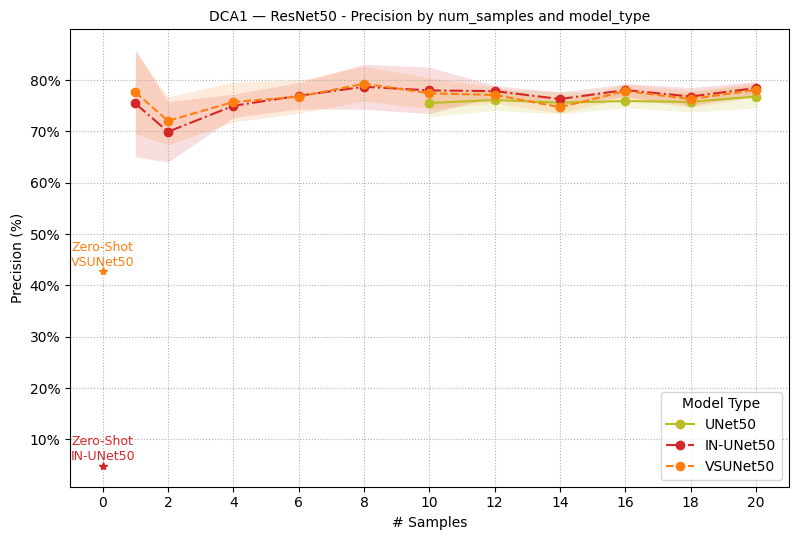

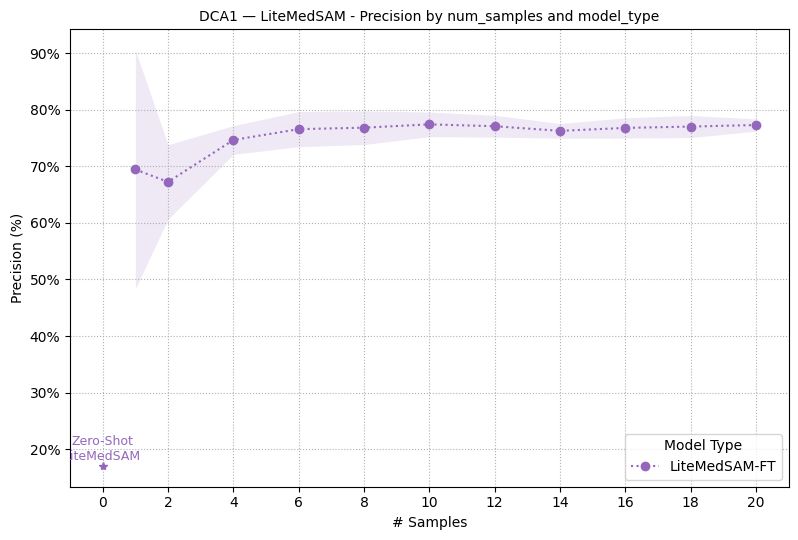

── Métrica: Recall ──


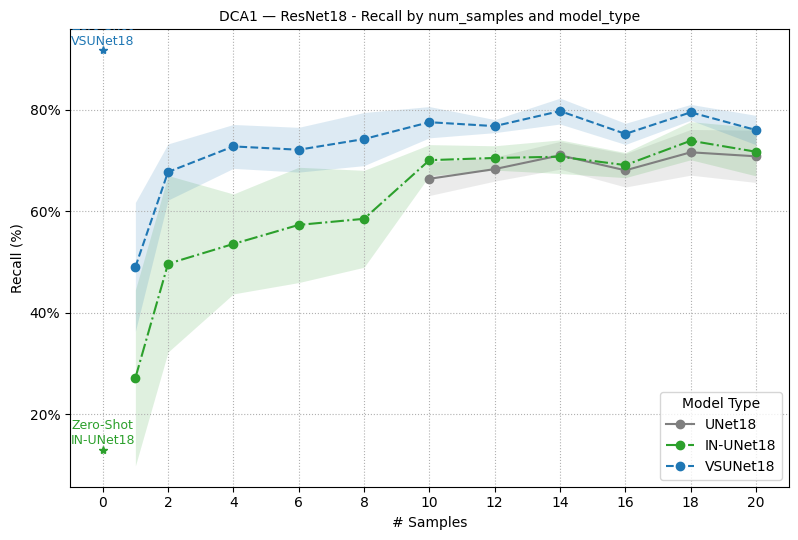

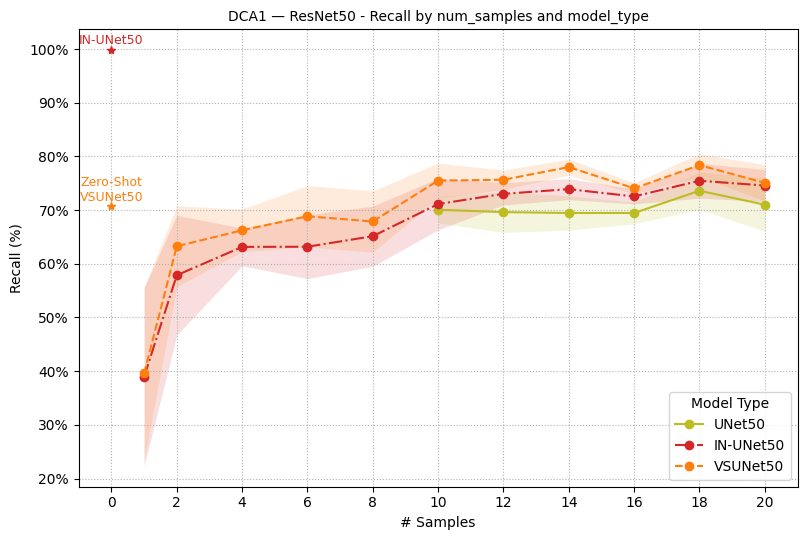

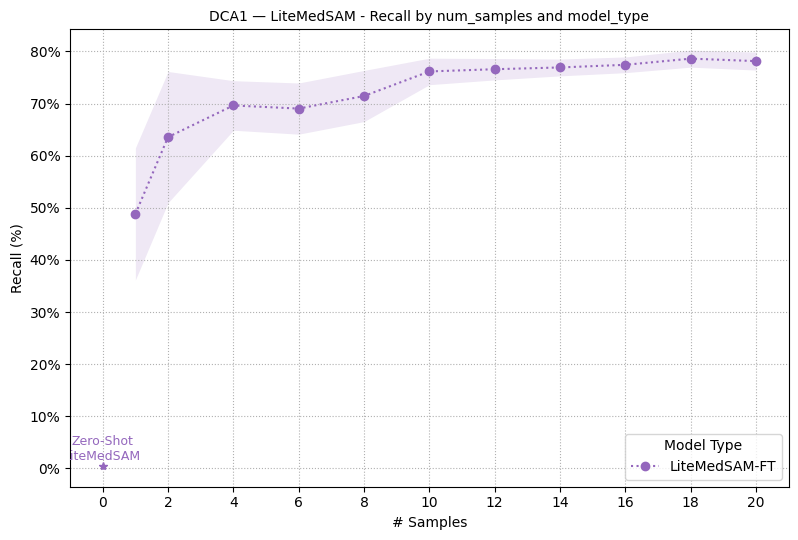

── Métrica: Dice ──


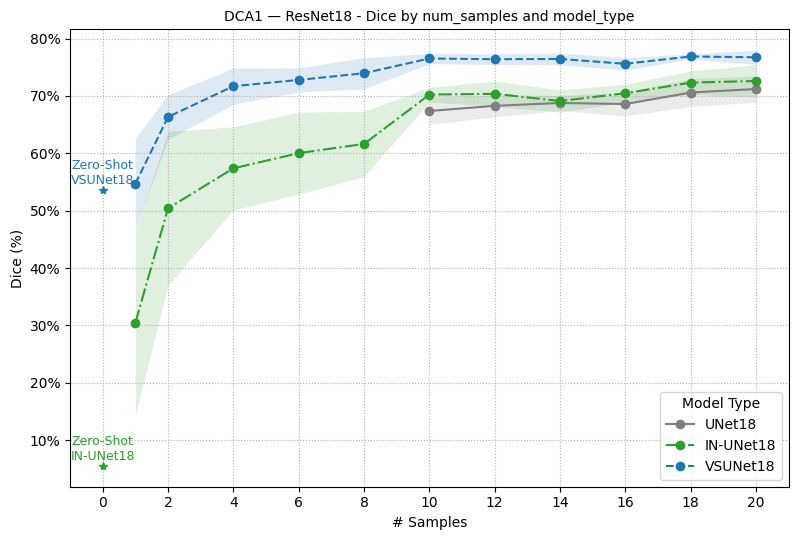

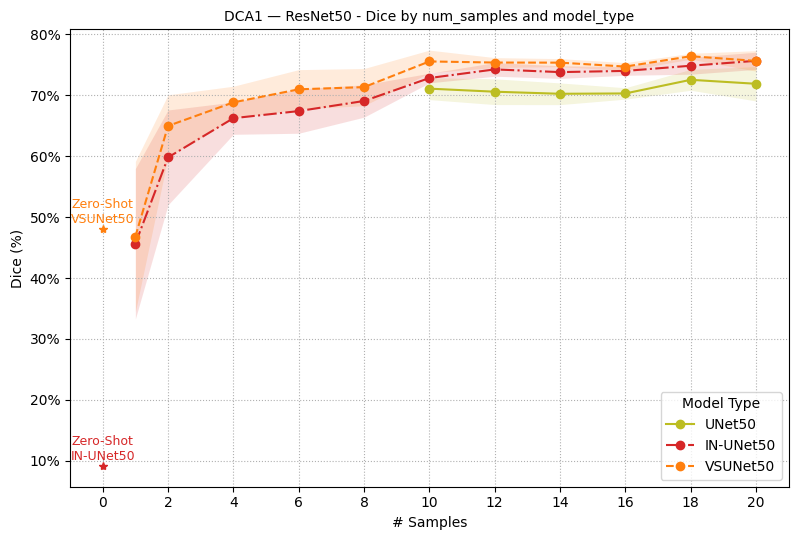

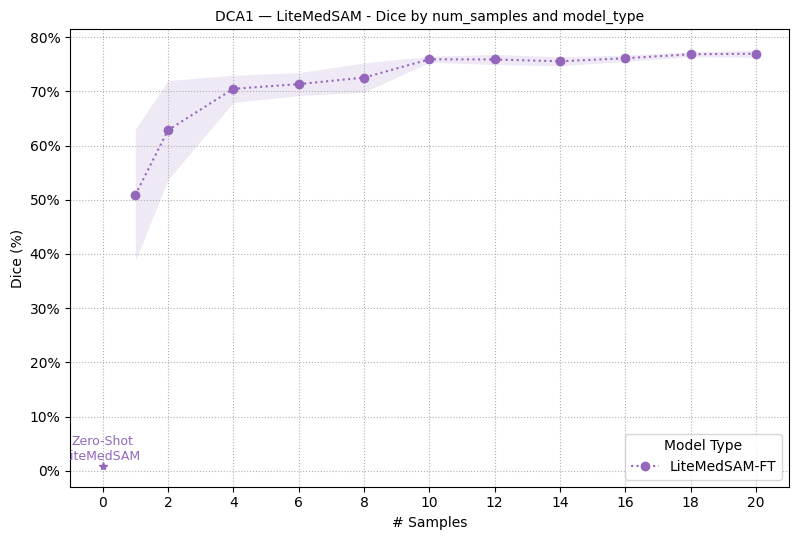

── Métrica: AUC ──


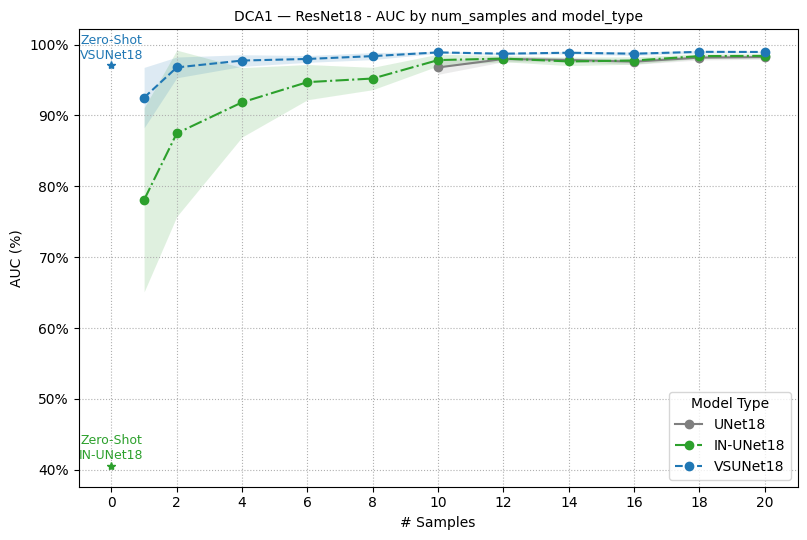

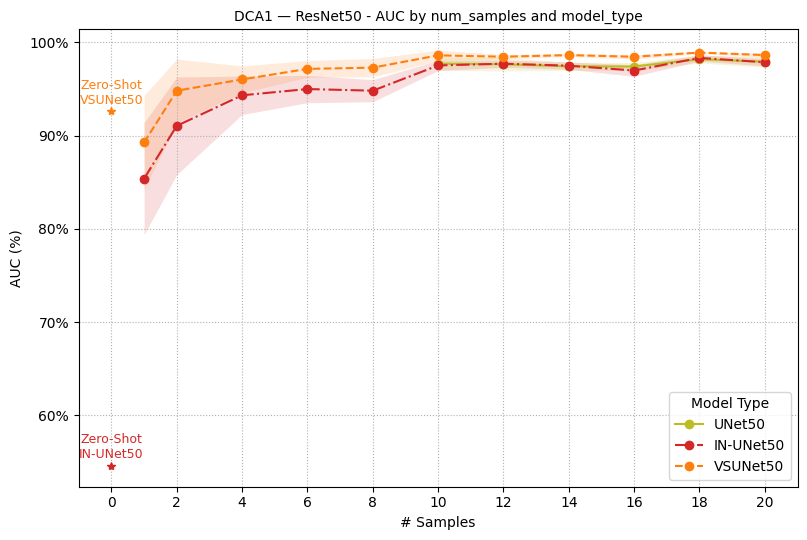

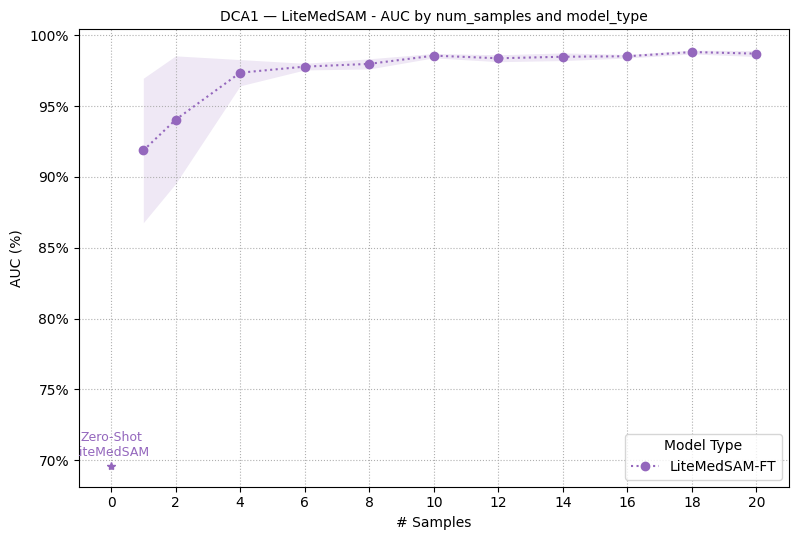

In [12]:
FAMILIES = [
    ('ResNet18',   ['UNet18', 'VSUNet18', 'IN-UNet18', 'Zero-Shot VSUNet18', 'Zero-Shot IN-UNet18', 'Zero-Shot VSUNet18 (mock)']),
    ('ResNet50',   ['UNet50', 'VSUNet50', 'IN-UNet50', 'Zero-Shot VSUNet50', 'Zero-Shot IN-UNet50', 'Zero-Shot VSUNet50 (mock)']),
    ('LiteMedSAM', ['LiteMedSAM-FT', 'Zero-Shot LiteMedSAM', 'Zero-Shot LiteMedSAM+IN']),
]

for metric in METRICS:
    print(f'── Métrica: {metric} ──')
    for fam_name, fam_labels in FAMILIES:
        sub = df[df['model_type'].isin(fam_labels)]
        if sub.empty:
            print(f'  [INFO] Sem dados para {fam_name}.')
            continue
        plot_mean_dice_score(
            sub,
            dataset_name=f'DCA1 — {fam_name}',
            hue='model_type',
            x_data='num_samples',
            y_data=metric,
            line_styles=line_styles,
            color_map_override=PALETTE,
            annotate_zero_shot=True,
            legend_title='Model Type',
            xlabel='# Samples',
            percentage=True,
            save_path=os.path.join(FIGURES_DIR, f'dca1_{fam_name.lower()}_{metric.lower()}.svg'),
            figsize=(8, 5.5),
            legend_loc='lower right',
            share_zero_shot_color_with='finetuned',
        )